# Phishing Website Detection using Machine Learning

## Notebook 06: Hyperparameter Tuning

### Objective

The objective of this notebook is to improve the performance of the best baseline machine learning models by tuning their hyperparameters using GridSearchCV. The tuned models will then be evaluated and compared to identify the best-performing optimized model.

---


## 1. Import Libraries

Import the required libraries for hyperparameter tuning, model evaluation, and saving the optimized models.

In [2]:
# Load saved preprocessing objects and save trained models
import joblib

import pandas as pd
import numpy as np

# GridSearchCV for hyperparameter tuning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## 2. Load the Engineered Dataset

Load the engineered phishing website dataset created in the previous notebook (notebook 4).

In [3]:
df = pd.read_csv("../dataset/engineered_phishing_dataset.csv")

df.head()

,num_dots_url,num_hyph_url,num_underline_url,num_slash_url,num_questionmark_url,num_equal_url,at_sign_url,num_exclamation_url,num_space_url,tilde_url,...,at_sign_param,num_exclamation_param,num_space_param,tilde_param,num_comma_param,num_plus_param,num_asterisk_param,num_percent_param,tld_in_param,phishing
0,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,5,1,0,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Split Dataset

In [4]:
X = df.drop("phishing", axis=1)
y = df["phishing"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
# X_train = joblib.load("../models/preprocessed_data/X_train.pkl")
# X_test = joblib.load("../models/preprocessed_data/X_test.pkl")

# y_train = joblib.load("../models/preprocessed_data//y_train.pkl")
# y_test = joblib.load("../models/preprocessed_data/y_test.pkl")



## 4. Create Helper Functions

Create reusable helper functions for hyperparameter tuning, model evaluation, confusion matrix visualization, and model saving.

### 4.1 Tune Model

Create a function to find the best hyperparameter combination using GridSearchCV.

In [5]:
def tune_model(model, param_grid, X_train, y_train):
    """
    Perform hyperparameter tuning using GridSearchCV.
    """

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X_train, y_train)

    return grid_search

### 4.2 Evaluate Model

Create a function to evaluate the performance of a tuned machine learning model.

In [6]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate a tuned model and return performance metrics.
    """

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

### 6.3 Confusion Matrix

Create a function to visualize the classification performance of a tuned model.

In [7]:
def plot_confusion_matrix(model, X_test, y_test):
    """
    Plot the confusion matrix.
    """

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Legitimate", "Phishing"]
    ).plot(cmap="Blues")

    plt.title("Confusion Matrix")
    plt.show()

### 6.4 Save Tuned Model

Create a function to save the tuned machine learning model.

In [8]:
def save_trained_model(model, model_name):
    """
    Save a tuned machine learning model.
    """

    joblib.dump(model, f"../models/tuned/{model_name}.pkl")

    print(f"{model_name} model saved successfully.")

---

# Hyperparameter Tuning

In [9]:
# create a single comparison table 
results={}


## 7. Random Forest Hyperparameter Tuning

**Question:** Can the performance of the Random Forest model be improved by selecting better hyperparameter values?

Define a set of candidate hyperparameters and use GridSearchCV to identify the best combination for the Random Forest classifier.

### 7.1 Define the Hyperparameter Grid

Specify the hyperparameter values that will be explored during the tuning process.

In [10]:
random_forest_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

### 7.2 Tune the Random Forest Model

Use GridSearchCV to identify the best hyperparameter combination for the Random Forest classifier.

In [11]:
random_forest_grid = tune_model(
    RandomForestClassifier(random_state=42),
    random_forest_params,
    X_train,
    y_train
)

### 7.3 Best Hyperparameters

Display the optimal hyperparameter values selected by GridSearchCV.

In [12]:
print("Best Hyperparameters:\n")

for parameter, value in random_forest_grid.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation F1 Score: {random_forest_grid.best_score_:.4f}")


Best Hyperparameters:

max_depth: 10
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 100

Best Cross-Validation F1 Score: 0.8983


### 7.4 Evaluate the Tuned Model

Evaluate the optimized Random Forest model on the testing dataset.

In [13]:
best_random_forest = random_forest_grid.best_estimator_

rf_metrics = evaluate_model(
    best_random_forest,
    X_test,
    y_test
)


### 7.5 Confusion Matrix

Visualize the classification performance of the tuned Random Forest model.

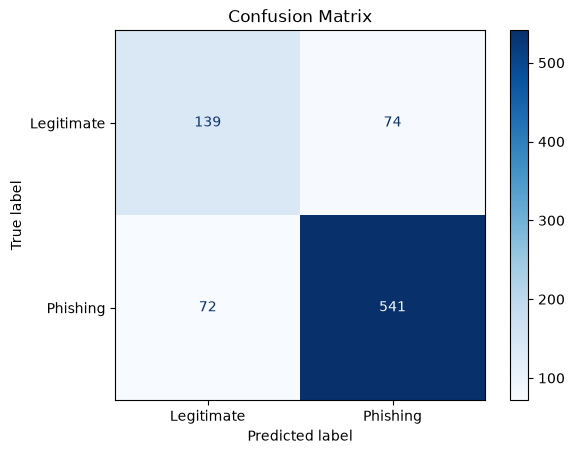

In [14]:
plot_confusion_matrix(
    best_random_forest,
    X_test,
    y_test
)

### 7.6 Save the Tuned Model

Save the optimized Random Forest model for future use.

In [15]:
save_trained_model(
    best_random_forest,
    "random_forest"
)

random_forest model saved successfully.


### 7.7 Store the Results

Store the evaluation metrics of the tuned Random Forest model for later comparison.

In [16]:
results["Random Forest"] = rf_metrics

## 8. XGBoost Hyperparameter Tuning

Define a set of candidate hyperparameters and use GridSearchCV to identify the optimal configuration for the XGBoost classifier.

### 8.1 Define the Hyperparameter Grid

Specify the hyperparameter values that will be explored during the tuning process.

In [17]:
xgboost_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 6],
    "subsample": [0.8, 1.0]
}

### 8.2 Tune the XGBoost Model

Use GridSearchCV to identify the best hyperparameter combination for the XGBoost classifier.

In [18]:
xgboost_grid = tune_model(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    xgboost_params,
    X_train,
    y_train
)

### 8.3 Best Hyperparameters

Display the optimal hyperparameter values selected by GridSearchCV.

In [19]:
print("Best Hyperparameters:\n")

for parameter, value in xgboost_grid.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation F1 Score: {xgboost_grid.best_score_:.4f}")

Best Hyperparameters:

learning_rate: 0.1
max_depth: 3
n_estimators: 200
subsample: 0.8

Best Cross-Validation F1 Score: 0.8986


### 8.4 Evaluate the Tuned Model

Evaluate the optimized Random Forest model on the testing dataset.

In [20]:
best_xgboost = xgboost_grid.best_estimator_

xgboost_metrics = evaluate_model(
    best_xgboost,
    X_test,
    y_test
)


### 8.5 Confusion Matrix

Visualize the classification performance of the tuned Random Forest model.

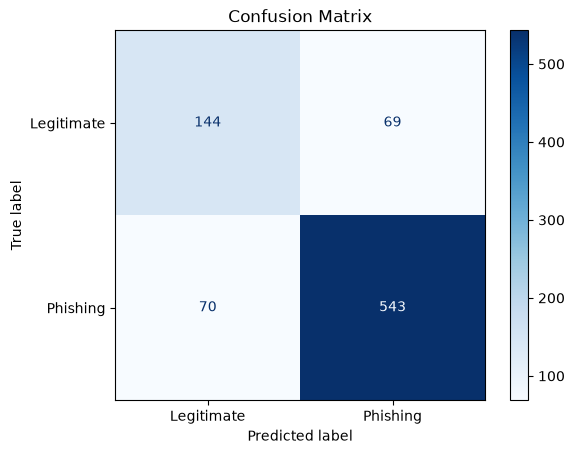

In [21]:
plot_confusion_matrix(
    best_xgboost,
    X_test,
    y_test
)

### 8.6 Save the Tuned Model

Save the optimized Random Forest model for future use.

In [22]:
save_trained_model(
    best_xgboost,
    "xgboost"
)

xgboost model saved successfully.


### 8.7 Store the Results

Store the evaluation metrics of the tuned Random Forest model for later comparison.

In [23]:
results["XGBoost"] = xgboost_metrics


## 9. LightGBM Hyperparameter Tuning

Define a set of candidate hyperparameters and use GridSearchCV to identify the optimal configuration for the LightGBM classifier.

### 9.1 Define the Hyperparameter Grid

Specify the hyperparameter values that will be explored during the tuning process.

In [24]:
lightgbm_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 6],
    "num_leaves": [31, 50]
}

### 9.2 Tune the LightGBM Model

Use GridSearchCV to identify the best hyperparameter combination for the LightGBM classifier.

In [25]:
lightgbm_grid = tune_model(
    LGBMClassifier(
        random_state=42,
        verbose=-1
    ),
    lightgbm_params,
    X_train,
    y_train
)

### 9.3 Best Hyperparameters

Display the optimal hyperparameter values selected by GridSearchCV.

In [26]:
print("Best Hyperparameters:\n")

for parameter, value in lightgbm_grid.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation F1 Score: {lightgbm_grid.best_score_:.4f}")

Best Hyperparameters:

learning_rate: 0.1
max_depth: 6
n_estimators: 100
num_leaves: 31

Best Cross-Validation F1 Score: 0.8983


### 9.4 Evaluate the Tuned Model

Evaluate the optimized LightGBM on the testing dataset.

In [27]:
best_lightgbm = lightgbm_grid.best_estimator_

lightgbm_metrics = evaluate_model(
    best_lightgbm,
    X_test,
    y_test
)


### 9.5 Confusion Matrix

Visualize the classification performance of the tuned LightBoost model.

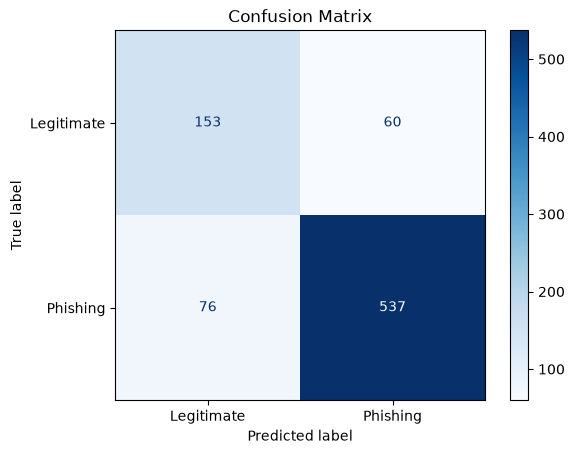

In [28]:
plot_confusion_matrix(
    best_lightgbm,
    X_test,
    y_test
)

### 9.6 Save the Tuned Model

Save the optimized LightGBM model for future use.

In [29]:
save_trained_model(
    best_lightgbm,
    "lightgbm"
)

lightgbm model saved successfully.


### 9.7 Store the Results

Store the evaluation metrics of the tuned LightGBM model for later comparison.

In [30]:
results["LightGBM"] = lightgbm_metrics


## 10. CatBoost Hyperparameter Tuning

Define a set of candidate hyperparameters and use GridSearchCV to identify the optimal configuration for the CatBoost classifier.

### 10.1 Define the Hyperparameter Grid

Specify the hyperparameter values that will be explored during the tuning process.

In [31]:
catboost_params = {
    "iterations": [100, 200],
    "learning_rate": [0.01, 0.1],
    "depth": [4, 6],
    "l2_leaf_reg": [3, 5]
}

### 10.2 Tune the CatBoost Model

Use GridSearchCV to identify the best hyperparameter combination for the CatBoost classifier.

In [32]:
catboost_grid = tune_model(
    CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    catboost_params,
    X_train,
    y_train
)

### 10.3 Best Hyperparameters

Display the optimal hyperparameter values selected by GridSearchCV.

In [33]:
print("Best Hyperparameters:\n")

for parameter, value in catboost_grid.best_params_.items():
    print(f"{parameter}: {value}")

print(f"\nBest Cross-Validation F1 Score: {catboost_grid.best_score_:.4f}")

Best Hyperparameters:

depth: 4
iterations: 100
l2_leaf_reg: 3
learning_rate: 0.1

Best Cross-Validation F1 Score: 0.9020


### 10.4 Evaluate the Tuned Model

Evaluate the optimized CatBoost model on the testing dataset.

In [34]:
best_catboost = catboost_grid.best_estimator_

catboost_metrics = evaluate_model(
    best_catboost,
    X_test,
    y_test
)


### 10.5 Confusion Matrix

Visualize the classification performance of the tuned CatBoost model.

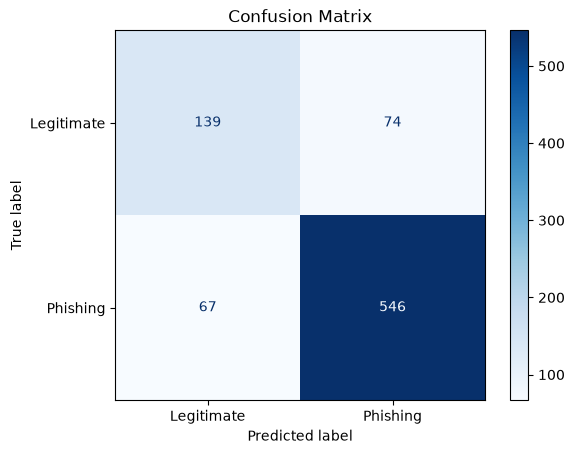

In [35]:
plot_confusion_matrix(
    best_catboost,
    X_test,
    y_test
)

### 10.6 Save the Tuned Model

Save the optimized CatBoost model for future use.

In [36]:
save_trained_model(
    best_catboost,
    "catboost"
)

catboost model saved successfully.


### 10.7 Store the Results

Store the evaluation metrics of the tuned CatBoost model for later comparison.

In [37]:
results["CatBoost"] = catboost_metrics

## 11. Compare the Tuned Models

Create a comparison table of the tuned machine learning models using the evaluation metrics.

In [38]:
results_df = pd.DataFrame(results).T

results_df = results_df.round(4)

results_df

,Accuracy,Precision,Recall,F1 Score
Random Forest,0.8232,0.8797,0.8825,0.8811
XGBoost,0.8317,0.8873,0.8858,0.8865
LightGBM,0.8354,0.8995,0.8760,0.8876
CatBoost,0.8293,0.8806,0.8907,0.8856


## 12. Rank the Tuned Models

Sort the tuned machine learning models based on their classification performance to identify the best optimized model.

In [39]:
results_df = results_df.sort_values(
    by=["Accuracy", "F1 Score"],
    ascending=False
)

results_df

,Accuracy,Precision,Recall,F1 Score
LightGBM,0.8354,0.8995,0.8760,0.8876
XGBoost,0.8317,0.8873,0.8858,0.8865
CatBoost,0.8293,0.8806,0.8907,0.8856
Random Forest,0.8232,0.8797,0.8825,0.8811


### Interpretation

- The tuned models are ranked based on **Accuracy**, with **F1 Score** used as a secondary criterion.
- Higher values indicate better classification performance.
- The highest-ranked model is selected as the final optimized model.

---

## 13. Identify the Best Tuned Model

Identify the highest-performing tuned machine learning model based on the comparison results.

In [40]:
best_model = results_df.index[0]

print(f"Best Tuned Model: {best_model}")


Best Tuned Model: LightGBM


## 14. Save the Comparison Table

Save the tuned model comparison table for future reference.

In [41]:
results_df.to_csv(
    "../reports/tuned_model_results.csv"
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


## 15. Compare Baseline and Tuned Performance

Compare the baseline and tuned machine learning models using **F1 Score**, which provides a balanced measure of Precision and Recall and is more suitable for the imbalanced phishing website dataset.

In [43]:
baseline_results = {
    "Random Forest": 0.8661,
    "XGBoost": 0.8772,
    "LightGBM": 0.8812,
    "CatBoost": 0.8856
}

comparison_df = pd.DataFrame({
    "Baseline F1 Score": pd.Series(baseline_results),
    "Tuned F1 Score": results_df["F1 Score"]
})

comparison_df["Improvement"] = (
    comparison_df["Tuned F1 Score"] -
    comparison_df["Baseline F1 Score"]
)

comparison_df = comparison_df.round(4)

comparison_df["Improvement"] = comparison_df["Improvement"].map(
    lambda x: f"{x:+.4f}"
)

comparison_df

,Baseline F1 Score,Tuned F1 Score,Improvement
CatBoost,0.8856,0.8856,+0.0000
LightGBM,0.8812,0.8876,+0.0064
Random Forest,0.8661,0.8811,+0.0150
XGBoost,0.8772,0.8865,+0.0093


### Interpretation

- The baseline and tuned models are compared using **F1 Score**, which is the primary evaluation metric for this imbalanced dataset.
- Hyperparameter tuning improved the F1 Score of **Random Forest**, **XGBoost**, and **LightGBM**.
- **CatBoost** maintained nearly the same performance after tuning.
- Overall, **LightGBM** achieved the highest F1 Score among the tuned models.

## 15. Key Findings

- Four ensemble machine learning models were optimized using **GridSearchCV**.
- Hyperparameter tuning improved the **F1 Score** of **Random Forest**, **XGBoost**, and **LightGBM**, while **CatBoost** maintained comparable performance.
- The tuned models were evaluated using **Accuracy, Precision, Recall, and F1 Score**.
- The baseline and tuned models were compared using **F1 Score**, which is more suitable for the imbalanced phishing website dataset.
- **LightGBM** achieved the best overall performance among the tuned models.
- The tuned models and comparison table were saved for future use.

## 16. Conclusion

- This notebook optimized four ensemble machine learning models using GridSearchCV and compared their performance with the corresponding baseline models. 
- Hyperparameter tuning improved the performance of Random Forest, XGBoost, and LightGBM, while CatBoost maintained comparable performance. 
- Among the tuned models, **LightGBM** achieved the best overall performance and was selected as the final optimized model for further evaluation.